In [6]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
print('done')

done


# Initial play around

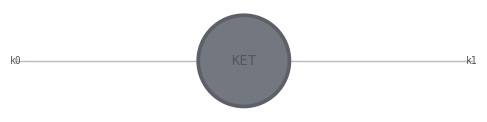

In [19]:
data = qu.bell_state('psi-').reshape(2, 2)
inds = ('k0', 'k1')
tags = ('KET',)

ket = qtn.Tensor(data=data, inds=inds, tags=tags)
ket.draw()

In [20]:
X = qtn.Tensor(qu.pauli('X'), inds=('k0', 'b0'), tags=['PAULI', 'X', '0'])
Y = qtn.Tensor(qu.pauli('Y'), inds=('k1', 'b1'), tags=['PAULI', 'Y', '1'])
bra = qtn.Tensor(qu.rand_ket(4).reshape(2, 2), inds=('b0', 'b1'), tags=['BRA'])

In [4]:
TN = ket.H & X & Y & bra
print(TN)


TensorNetwork([
    Tensor(shape=(2, 2), inds=('k0', 'k1'), tags=oset(['KET'])),
    Tensor(shape=(2, 2), inds=('k0', 'b0'), tags=oset(['PAULI', 'X', '0'])),
    Tensor(shape=(2, 2), inds=('k1', 'b1'), tags=oset(['PAULI', 'Y', '1'])),
    Tensor(shape=(2, 2), inds=('b0', 'b1'), tags=oset(['BRA'])),
], tensors=4, indices=4)


In [5]:
for i in TN:
    print(i.tags)
    print(i.data)
    print('---')

oset(['KET'])
[[ 0.        -0.j  0.70710678-0.j]
 [-0.70710678-0.j  0.        -0.j]]
---
oset(['PAULI', 'X', '0'])
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
---
oset(['PAULI', 'Y', '1'])
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
---
oset(['BRA'])
[[ 0.19493641-0.06546445j  0.05539121+0.21935611j]
 [-0.62735275+0.31297469j -0.60817086+0.21244407j]]
---


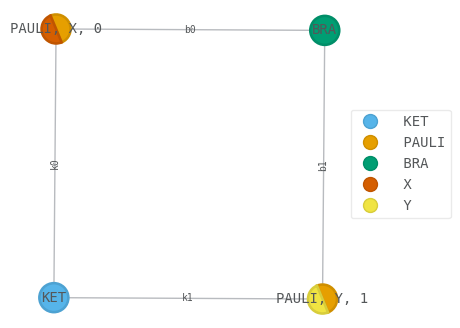

In [6]:
TN.draw(color=['KET', 'PAULI', 'BRA', 'X', 'Y'], figsize=(4, 4), show_inds='all')

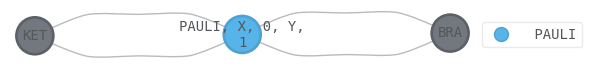

TensorNetwork([
    Tensor(shape=(2, 2), inds=('k0', 'k1'), tags=oset(['KET'])),
    Tensor(shape=(2, 2), inds=('b0', 'b1'), tags=oset(['BRA'])),
    Tensor(shape=(2, 2, 2, 2), inds=('k0', 'b0', 'k1', 'b1'), tags=oset(['PAULI', 'X', '0', 'Y', '1'])),
], tensors=3, indices=4)
oset(['KET'])
[[ 0.        -0.j  0.70710678-0.j]
 [-0.70710678-0.j  0.        -0.j]]
---
oset(['BRA'])
[[ 0.19493641-0.06546445j  0.05539121+0.21935611j]
 [-0.62735275+0.31297469j -0.60817086+0.21244407j]]
---
oset(['PAULI', 'X', '0', 'Y', '1'])
[[[[0.+0.j 0.-0.j]
   [0.+0.j 0.+0.j]]

  [[0.+0.j 0.-1.j]
   [0.+1.j 0.+0.j]]]


 [[[0.+0.j 0.-1.j]
   [0.+1.j 0.+0.j]]

  [[0.+0.j 0.-0.j]
   [0.+0.j 0.+0.j]]]]
---


In [7]:
TNc = TN ^ 'PAULI'
TNc.draw('PAULI')
print(TNc)
for i in TNc:
    print(i.tags)
    print(i.data)
    print('---')

# One qubit quantum gate

## Defining elements

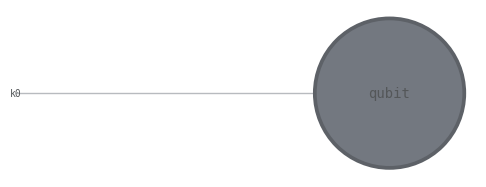

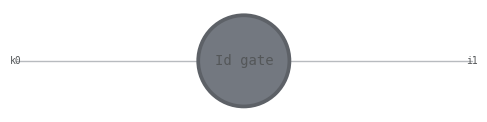

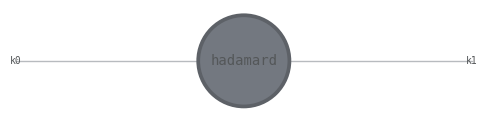

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [37]:
# qubit state vec

qubit = qtn.Tensor(data = [0,1],inds=['k0'],tags=['qubit'])

# one-qubit gate mat

id = qtn.Tensor(data = [[1,0],[0,1]],inds=['k0','i1'],tags = ['Id gate'])
had = qtn.Tensor(data = [[1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),-1/np.sqrt(2)]],inds=['k0','k1'],tags = ['hadamard'])

qubit.draw()
id.draw()
had.draw()

# accessing values
had.data

## Linking elements

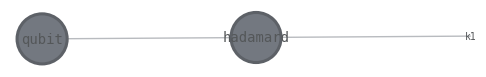

In [38]:
TN = qubit & had
TN.draw()

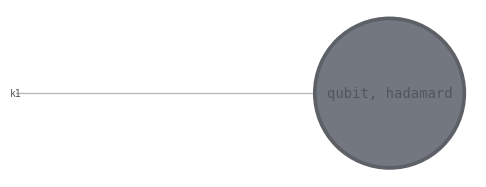

array([ 0.70710678, -0.70710678])

In [40]:
result = qubit @ had
result.draw()
result.data

# Two qubit gate

In [107]:
state1 = np.array([1,0])
state2 = np.array([1,0])
np.concatenate((state1[0]*state2,state1[1]*state2))

state = np.array([0,0,0,1])
state1_back = [state[0]+state[1],state[2]+state[3]]
state2_back = [state[0]+state[2],state[1]+state[3]]
state1_back,state2_back

def two_to_one(qb1,qb2):
    return np.concatenate((qb1[0]*qb2,qb1[1]*qb2))
def one_to_two(qb):
    return np.array([qb[0]+qb[1],qb[2]+qb[3]]),np.array([qb[0]+qb[2],qb[1]+qb[3]])

one_to_two(np.array([0,1,0,0]))

(array([1, 0]), array([0, 1]))

initial state is  [0 1] ,  [1 0]
wich is  [0 0 1 0]
output is 
 [[0 0]
 [0 1]]
wich is  (array([0, 1]), array([0, 1]))


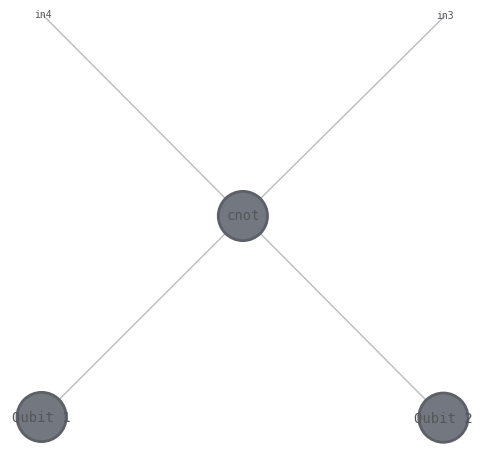

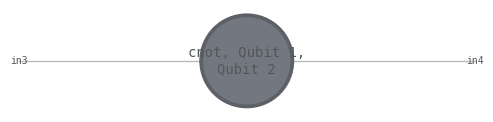

In [109]:
cnot = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]]).reshape(2,2,2,2),
                    inds = ['in1','in2','in3','in4'],tags = ['cnot'])


state1 = np.array([0,1])
state2 = np.array([1,0])

print('initial state is ',state1,', ',state2)
print('wich is ',two_to_one(state1,state2))

qb1 = qtn.Tensor(data=state1,inds=['in1'],tags = ['Qubit 1'])
qb2 = qtn.Tensor(data=state2,inds=['in2'],tags = ['Qubit 2'])

TN = cnot & qb1 & qb2

TNc  = TN ^ ...

print('output is \n',TNc.data)
print('wich is ',one_to_two(np.concatenate((TNc.data[0],TNc.data[1]))))
TN.draw()
TNc.draw()

initial state is  [0 1] ,  [1 0]
wich is  [0 0 1 0]


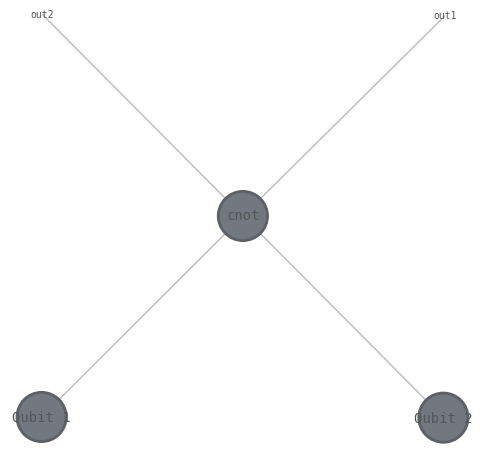

output is 
 [[0. 0.]
 [0. 1.]]
wich is  (array([0., 1.]), array([0., 1.]))


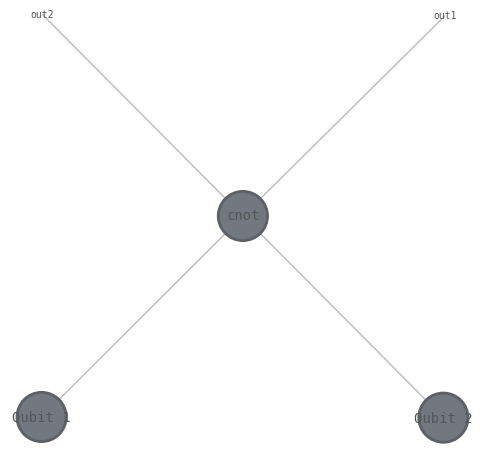

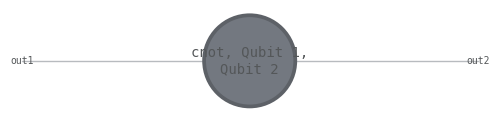

In [169]:
cnot = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=float).reshape(2,2,2,2),
                    inds = ['in1','in2','out1','out2'],tags = ['cnot'])


state1 = np.array([0,1])
state2 = np.array([1,0])

print('initial state is ',state1,', ',state2)
print('wich is ',two_to_one(state1,state2))

qb1 = qtn.Tensor(data=state1,inds=['in1'],tags = ['Qubit 1'])
qb2 = qtn.Tensor(data=state2,inds=['in2'],tags = ['Qubit 2'])

TN = cnot & qb1 & qb2

TN.draw()

TNc  = TN ^ ...

print('output is \n',TNc.data)
print('wich is ',one_to_two(np.concatenate((TNc.data[0],TNc.data[1]))))
TN.draw()
TNc.draw()

# split tensor

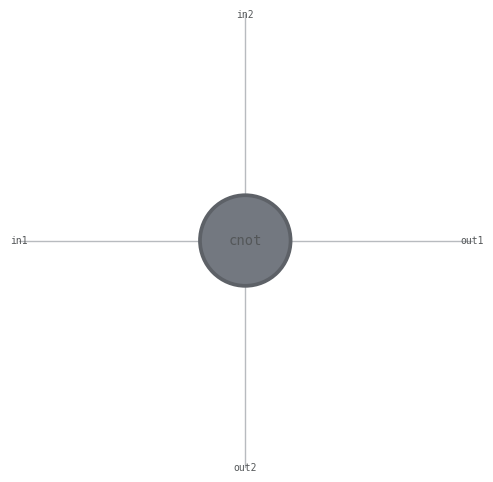

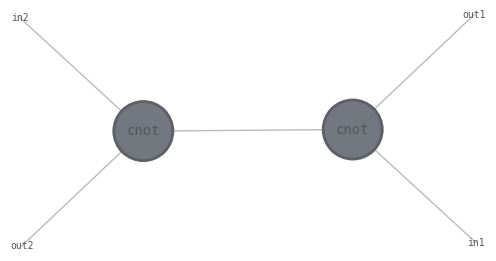

In [4]:
cnot = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=float).reshape(2,2,2,2),
                    inds = ['in1','in2','out1','out2'],tags = ['cnot'])

cnot.draw()
cnot = cnot.split(left_inds=['in1','out1'])
cnot.draw()

# making MPS

initial state is  [0 1] ,  [1 0]
wich is  [0 0 1 0]


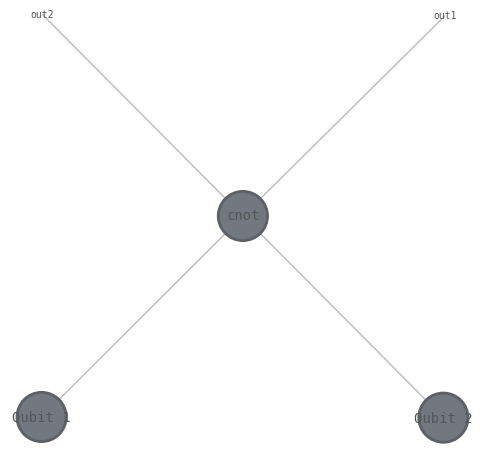

output is 
 [[0. 0.]
 [0. 1.]]
wich is  (array([0., 1.]), array([0., 1.]))


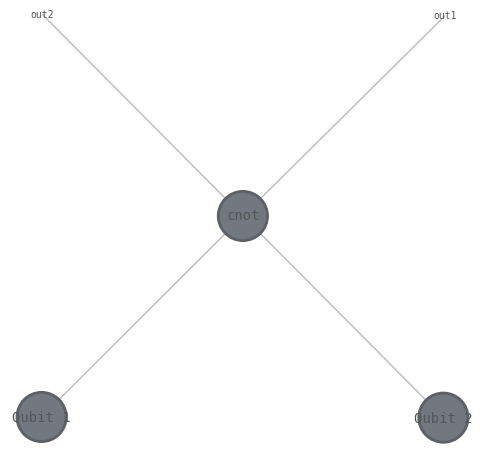

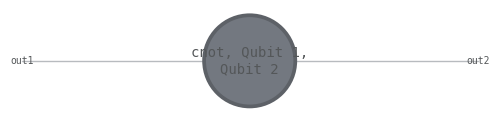

In [ ]:
cnot = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=float).reshape(2,2,2,2),
                    inds = ['in1','in2','out1','out2'],tags = ['cnot'])

state1 = np.array([0,1])
state2 = np.array([1,0])

qb1 = qtn.Tensor(data=state1,inds=['in1'],tags = ['Qubit 1'])
qb2 = qtn.Tensor(data=state2,inds=['in2'],tags = ['Qubit 2'])

print('initial state is ',state1,', ',state2)
print('wich is ',two_to_one(state1,state2))

TN = cnot & qb1 & qb2

TN.draw()

TNc  = TN ^ ...

print('output is \n',TNc.data)
print('wich is ',one_to_two(np.concatenate((TNc.data[0],TNc.data[1]))))
TN.draw()
TNc.draw()

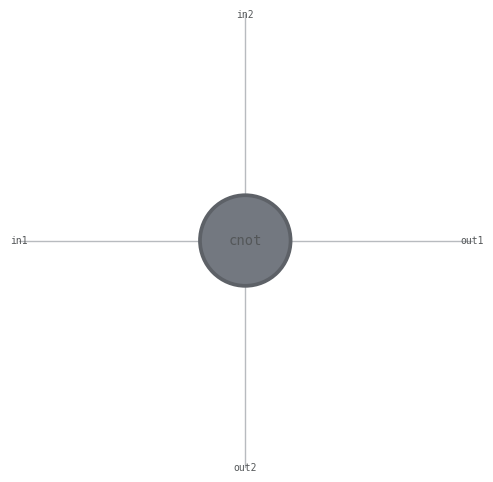

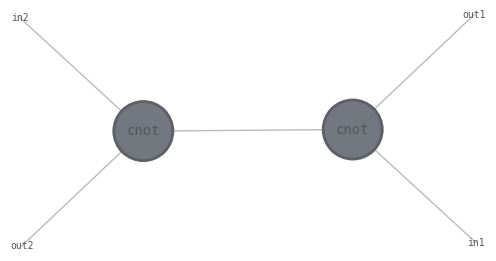

In [ ]:
cnot = qtn.Tensor(data=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=float).reshape(2,2,2,2),
                    inds = ['in1','in2','out1','out2'],tags = ['cnot'])

cnot.draw()
cnot = cnot.split(left_inds=['in1','out1'])
cnot.draw()

# Quantum circuits/MPS

## Tests

In [175]:
import random
import quimb as qu
import quimb.tensor as qtn

N = 80
circ = qtn.Circuit(N)

# randomly permute the order of qubits
regs = list(range(N))
random.shuffle(regs)

# hamadard on one of the qubits
circ.apply_gate('H', regs[0])

# chain of cnots to generate GHZ-state
for i in range(N - 1):
    circ.apply_gate('CNOT', regs[i], regs[i + 1])

# apply multi-controlled NOT
circ.apply_gate('X', regs[-1], controls=regs[:-1])

# sample it a few times
for b in circ.sample(1, seed=42):
    print(b)

c:\Users\titou\miniforge3\envs\projetqte\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


11111111111111111111111111111111111111111111111111111111111111111111101111111111


In [7]:
def gen_gates(N=64, x=0.1, depth=10, seed=42):
    """Generate a long range circuit that only slowly builds up entanglement.

    Parameters
    ----------
    N : int, optional
        The number of qubits.
    x : float, optional
        The average angle magnitude of U3 rotations.
    depth : int, optional
        The number of fully entangling gate layers.
    seed : int, optional
        A random seed.

    Yields
    ------
    qtn.Gate
    """

    rng = np.random.default_rng(seed)
    qubits = list(range(N))

    for _ in range(depth):
        # random small single qubit rotations
        for q in qubits:
            yield qtn.Gate("U3", params=rng.normal(scale=x, size=3), qubits=[q])

        # random CZs between arbitrary qubit pairs
        rng.shuffle(qubits)
        for i in range(0, N, 2):
            qa = qubits[i]
            qb = qubits[i + 1]
            yield qtn.Gate("CZ", params=(), qubits=[qa, qb])

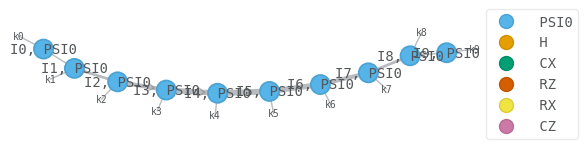

5.753374665573574e-09

In [4]:
N = 10
chi = 1
circ = qtn.CircuitMPS(N)
gates_generator = gen_gates(N=N)
for gate in list(gates_generator):
    circ.apply_gate(gate)
circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
circ.error_estimate()

In [5]:
list(circ.sample(10))

['0000000000',
 '0000000000',
 '0000000000',
 '0000000000',
 '0001000000',
 '0000000000',
 '0001000000',
 '0000000000',
 '0000000000',
 '1000000000']

## Graphs

In [8]:
import matplotlib.pyplot as plt
import random
import numpy as np
import quimb as qu
import quimb.tensor as qtn

# result1 = []
# result2 = []
range1 = range(1,100,2)
range2 = range(2,100,6) #must be pair
chi2 = 10
N = 32

def gen_gates(N=64, x=0.1, depth=10, seed=42):
    """Generate a long range circuit that only slowly builds up entanglement.

    Parameters
    ----------
    N : int, optional
        The number of qubits.
    x : float, optional
        The average angle magnitude of U3 rotations.
    depth : int, optional
        The number of fully entangling gate layers.
    seed : int, optional
        A random seed.

    Yields
    ------
    qtn.Gate
    """

    rng = np.random.default_rng(seed)
    qubits = list(range(N))

    for _ in range(depth):
        # random small single qubit rotations
        for q in qubits:
            yield qtn.Gate("U3", params=rng.normal(scale=x, size=3), qubits=[q])

        # random CZs between arbitrary qubit pairs
        rng.shuffle(qubits)
        for i in range(0, N, 2):
            qa = qubits[i]
            qb = qubits[i + 1]
            yield qtn.Gate("CZ", params=(), qubits=[qa, qb])



In [53]:
result1 = []
for i in range1:
    print('chi : ',i)
    chi = i
    circ = qtn.CircuitMPS(N,max_bond=chi)
    gates_generator = gen_gates(N=N)
    for gate in list(gates_generator):
        circ.apply_gate(gate)
    # circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
    result1.append(circ.error_estimate())

chi :  1
chi :  3
chi :  5
chi :  7
chi :  9
chi :  11
chi :  13
chi :  15
chi :  17
chi :  19
chi :  21
chi :  23
chi :  25
chi :  27
chi :  29
chi :  31
chi :  33
chi :  35
chi :  37
chi :  39
chi :  41
chi :  43
chi :  45
chi :  47
chi :  49
chi :  51
chi :  53
chi :  55
chi :  57
chi :  59
chi :  61
chi :  63
chi :  65
chi :  67
chi :  69
chi :  71
chi :  73
chi :  75
chi :  77
chi :  79
chi :  81
chi :  83
chi :  85
chi :  87
chi :  89
chi :  91
chi :  93
chi :  95
chi :  97
chi :  99


In [56]:
result2 = []
for i in range2:
    print('N : ',i )
    chi = 10
    N = i
    circ = qtn.CircuitMPS(N,max_bond=chi)
    gates_generator = gen_gates(N=N)
    for gate in list(gates_generator):
        circ.apply_gate(gate)
    # circ.psi.draw(color=['PSI0', 'H', 'CX', 'RZ', 'RX', 'CZ'])
    result2.append(circ.error_estimate())

N :  2
N :  8
N :  14
N :  20
N :  26
N :  32
N :  38
N :  44
N :  50
N :  56
N :  62
N :  68
N :  74
N :  80
N :  86
N :  92
N :  98


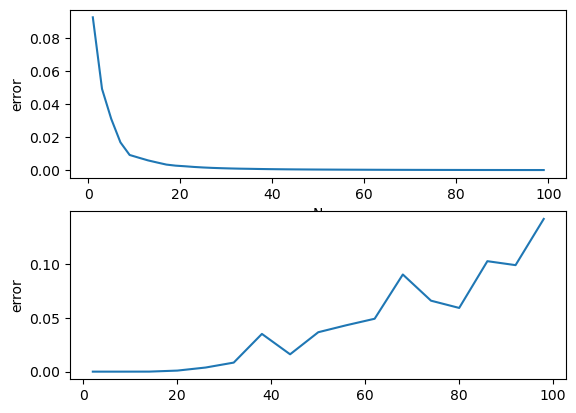

In [57]:
fig,axs = plt.subplots(2)

axs[0].plot(range1,result1)
axs[1].plot(range2,result2)

axs[0].set_ylabel('error')
axs[0].set_xlabel('Chi')
axs[1].set_ylabel('error')
axs[0].set_xlabel('N')

# axs[0].set_yscale('log')
# axs[1].set_yscale('log')

plt.show()

np.savetxt('result1.txt', result1, delimiter=',')
np.savetxt('result2.txt', result2, delimiter=',')

## 3D plot

In [61]:
import matplotlib.pyplot as plt
import random
import numpy as np
import quimb as qu
import quimb.tensor as qtn


def gen_gates(N=64, x=0.1, depth=10, seed=42):
    """Generate a long range circuit that only slowly builds up entanglement.

    Parameters
    ----------
    N : int, optional
        The number of qubits.
    x : float, optional
        The average angle magnitude of U3 rotations.
    depth : int, optional
        The number of fully entangling gate layers.
    seed : int, optional
        A random seed.

    Yields
    ------
    qtn.Gate
    """

    rng = np.random.default_rng(seed)
    qubits = list(range(N))

    for _ in range(depth):
        # random small single qubit rotations
        for q in qubits:
            yield qtn.Gate("U3", params=rng.normal(scale=x, size=3), qubits=[q])

        # random CZs between arbitrary qubit pairs
        rng.shuffle(qubits)
        for i in range(0, N, 2):
            qa = qubits[i]
            qb = qubits[i + 1]
            yield qtn.Gate("CZ", params=(), qubits=[qa, qb])



In [5]:
chi_values = []
N_values = []
error_values = []

chi_range = range(1,20,1) 
N_range = range(2,10,1)

def get_error(chi,N):
    circ = qtn.CircuitMPS(N=N,max_bond=chi)
    gates_generator = gen_gates(depth=N)
    for gate in list(gates_generator):
        circ.apply_gate(gate)
    return circ.error_estimate()

get_error_vec = np.vectorize(get_error)


X,Y = np.meshgrid(chi_range,N_range)
Z = get_error_vec(X,Y)


# for chi in chi_range:
#     for N in N_range:
#         print(chi,' ',N)
#         circ = qtn.CircuitMPS(N,max_bond=chi)
#         gates_generator = gen_gates(N=N)
#         for gate in list(gates_generator):
#             circ.apply_gate(gate)
#         chi_values.append(chi)
#         N_values.append(N)
#         error_values.append(circ.error_estimate)

NameError: name 'gen_gates' is not defined

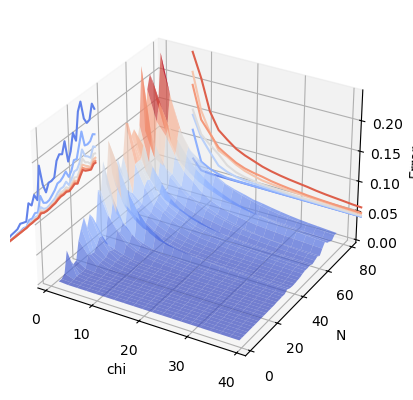

In [ ]:
import matplotlib.pyplot as plt

# from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, alpha = 0.7,cmap=.coolwarm) #, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8, alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
ax.contour(X, Y, Z, zdir='x', offset=-15, cmap='coolwarm')
ax.contour(X, Y, Z, zdir='y', offset=100, cmap='coolwarm')
ax.set_xlabel('chi')
ax.set_ylabel('N')
ax.set_zlabel('Error')

# ax.set(xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),xlabel='X', ylabel='Y', zlabel='Z')

plt.show()

np.savetxt('X.txt', X, delimiter=',')
np.savetxt('Y.txt', Y, delimiter=',')
np.savetxt('Z.txt', Z, delimiter=',')

C:\Users\titou\AppData\Local\Temp\ipykernel_4408\3232706739.py:7: RuntimeWarning: invalid value encountered in log
  Z = np.log(np.loadtxt('Z.txt', delimiter=','))


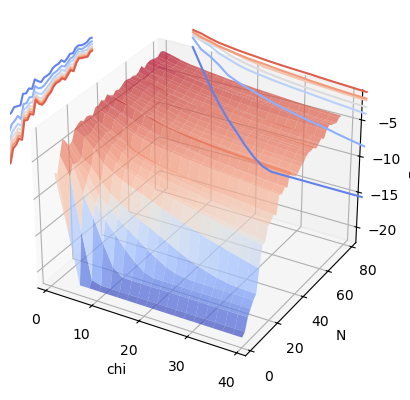

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import axes3d

X = np.loadtxt('X.txt',delimiter=',')
Y = np.loadtxt('Y.txt', delimiter=',')
Z = np.log(np.loadtxt('Z.txt', delimiter=','))

# from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, alpha = 0.7,cmap='coolwarm') #, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8, alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
ax.contour(X, Y, Z, zdir='x', offset=-15, cmap='coolwarm')
ax.contour(X, Y, Z, zdir='y', offset=100, cmap='coolwarm')
ax.set_xlabel('chi')
ax.set_ylabel('N')
ax.set_zlabel('Error')

# ax.set(xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),xlabel='X', ylabel='Y', zlabel='Z')

plt.show()



In [98]:
Z

array([[ 1.07693976e-03, -4.44089210e-16, -4.44089210e-16,
        -4.44089210e-16, -4.44089210e-16, -4.44089210e-16,
        -4.44089210e-16, -4.44089210e-16],
       [ 5.98571047e-03,  4.70002897e-07,  5.09064568e-10,
         5.09064568e-10,  5.09064568e-10,  5.09064568e-10,
         5.09064568e-10,  5.09064568e-10],
       [ 2.00881015e-02,  1.32238905e-04,  2.27139983e-06,
         9.68787460e-08,  9.04817354e-09,  5.75337467e-09,
         5.75337467e-09,  5.75337467e-09],
       [ 1.14062601e-02,  7.85447582e-04,  4.28801649e-05,
         8.33691915e-06,  2.16564190e-06,  5.48115114e-07,
         1.38216411e-07,  5.26694370e-08],
       [ 5.79568037e-02,  8.27048846e-03,  1.39341101e-03,
         4.96567367e-04,  2.15786496e-04,  1.05562853e-04,
         5.40402381e-05,  2.91036949e-05],
       [ 5.05214068e-02,  9.78847241e-03,  2.96734400e-03,
         9.27472687e-04,  4.95657797e-04,  3.02597120e-04,
         1.92810932e-04,  1.28810154e-04],
       [ 5.93900968e-02,  1.299467